In [68]:
import numpy as np
print(np.__version__)
print("NumPy fonctionne")

2.4.6
NumPy fonctionne


In [69]:
import numpy as np

arr = np.array([1, 2, 3, 4, 5]) #création tableau / affichage
print(arr)            # [1 2 3 4 5]

#tableaux de base 
np.zeros(5)           # [0. 0. 0. 0. 0.]
np.ones(5)            # [1. 1. 1. 1. 1.]
np.zeros((3, 4))      # matrice 3 lignes × 4 colonnes de zéros
np.full(5, 7.0)       # [7. 7. 7. 7. 7.]

#séquences régulières
np.arange(10)              # [0 1 2 3 4 5 6 7 8 9] — équivalent de range()
np.arange(0, 10, 2)        # [0 2 4 6 8] — start, stop, step
np.linspace(0, 1, 5)       # [0.   0.25 0.5  0.75 1.] — 5 points entre 0 et 1

#tableau aléatoires
np.random.rand(5)          # 5 nombres uniformes entre 0 et 1
np.random.randn(5)         # 5 nombres gaussiens (moyenne 0, écart-type 1)
np.random.normal(10, 2, 5) # 5 nombres gaussiens (moyenne 10, écart-type 2)
np.random.randint(0, 10, 5) # 5 entiers entre 0 (inclus) et 10 (exclus)

[1 2 3 4 5]


array([3, 6, 7, 2, 0], dtype=int32)

In [70]:
import numpy as np
np.random.seed(42)

x = np.random.randn(1000)
print(f"{'Moyenne':<12} : {x.mean():.4f}")
print(f"{'Médiane':<12} : {np.median(x):.4f}")
print(f"{'Écart-type':<12} : {x.std():.4f}")
print(f"{'Min':<12} : {x.min():.4f}")
print(f"{'Max':<12} : {x.max():.4f}")

Moyenne      : 0.0193
Médiane      : 0.0253
Écart-type   : 0.9787
Min          : -3.2413
Max          : 3.8527


In [71]:
import numpy as np
np.random.seed(42)

M = np.random.randint(0, 10, (5, 5))
print(M)
print(f"{'Diagonale':<12} : {np.diag(M)}")
print(f"{'Somme lignes':<12} : {M.sum(axis=1)}")
print(f"{'Somme colonnes':<12} : {M.sum(axis=0)}")
print(f"{'Transposee':<12} :")
print(M.T)
print(f"{'Matrice au carre':<12} : ")
print(M @ M)

[[6 3 7 4 6]
 [9 2 6 7 4]
 [3 7 7 2 5]
 [4 1 7 5 1]
 [4 0 9 5 8]]
Diagonale    : [6 2 7 5 8]
Somme lignes : [26 28 24 18 26]
Somme colonnes : [26 13 36 23 24]
Transposee   :
[[6 9 3 4 4]
 [3 2 7 1 0]
 [7 6 7 7 9]
 [4 7 2 5 5]
 [6 4 5 1 8]]
Matrice au carre : 
[[124  77 191 109 135]
 [134  80 202 117 131]
 [130  74 171 110 123]
 [ 78  68 127  67  76]
 [103  80 198  99 138]]


In [72]:
import numpy as np

prix = np.array([100, 102, 101, 105, 103, 107, 108, 110, 109, 112])
rendements = (prix[1:]-prix[:-1])/prix[:-1]
rendements_log = np.log(prix[1:]/prix[:-1])
rendement_cum_fin = (prix[-1] / prix[0]) - 1

print(f"{'Rendements simples':<12} : {rendements}")
print()
print(f"{'Rendements log':<12} : {rendements_log }")
print()
print(f"{'Rendement cumulé final':<12} : {rendement_cum_fin * 100 :.2f}")
print()
print(f"{'Rendement moyen quotidien':<12} : {rendements.mean() * 100 :.2f}")
print()
print(f"{'Vol quotidienne':<12} : {rendements.std() * 100 :.2f}")
print()

Rendements simples : [ 0.02       -0.00980392  0.03960396 -0.01904762  0.03883495  0.00934579
  0.01851852 -0.00909091  0.02752294]

Rendements log : [ 0.01980263 -0.0098523   0.03883983 -0.01923136  0.03809985  0.00930239
  0.01834914 -0.00913248  0.02715099]

Rendement cumulé final : 12.00

Rendement moyen quotidien : 1.29

Vol quotidienne : 2.03



In [73]:
import numpy as np

prix = np.array([100, 102, 101, 105, 103, 107, 108, 110, 109, 112])
rendements = (prix[1:]-prix[:-1])/prix[:-1]
vol = rendements.std()
JOURS_BOURSE = 252

rend_an = rendements.mean() * 252
vol_an = vol * np.sqrt(252)
sharp_rat = rend_an / vol_an

print(f"{'Rendement annualisé':<22} : {rend_an:.2%}")
print(f"{'Volatilité annualisée':<22} : {vol_an:.2%}")
print(f"{'Sharpe ratio':<22} : {sharp_rat:.4f}")

Rendement annualisé    : 324.47%
Volatilité annualisée  : 32.25%
Sharpe ratio           : 10.0621


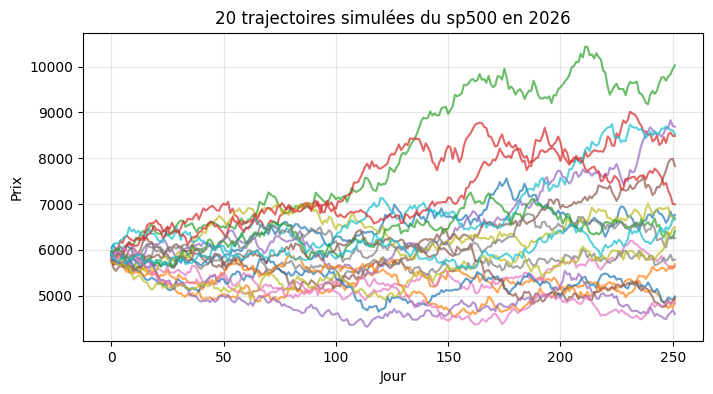

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

mu = 0.08       # rendement annuel attendu
sigma = 0.20    # volatilité annuelle
S0 = 5881        # prix initial
T = 252         # nombre de jours
dt = 1 / 252    # pas de temps quotidien (en années)

rendements_log = np.random.normal(
    loc=(mu - 0.5 * sigma**2) * dt,
    scale=sigma * np.sqrt(dt),
    size=T
   )
#print(rendements_log)

prix = S0 * np.exp(np.cumsum(rendements_log))


plt.figure(figsize=(8, 4))
for i in range(20):
    rdmts = np.random.normal(loc=(mu - 0.5*sigma**2)*dt, scale=sigma*np.sqrt(dt), size=T)
    traj = S0 * np.exp(np.cumsum(rdmts))
    plt.plot(traj, alpha=0.7)
plt.title("20 trajectoires simulées du sp500 en 2026")
plt.xlabel("Jour")
plt.ylabel("Prix")
plt.grid(True, alpha=0.3)
plt.show()